# AISO v5 — 삼체 역학 (Three-Body Dynamics)

## 핵심 변경

| | 원본 AISO | AISO v5 |
|---|---|---|
| **M 범위** | Uniform(0, 2) → 항상 당김 | **Uniform(-1, 2) → 밀기/무시/당기기** |
| **파트너** | 랜덤 1명 | **전체 에이전트 합력** |
| **이동 규칙** | `α·c_ij·(X_j - X_i)` | **`α · Σ_j c_ij·(X_j - X_i)`** |
| **핵심 수식** | `c_ij = W_i^T · M · W_j` | **동일 — 변경 없음** |

M에 음수가 생기면 `c_ij`가 음수 → X_j 반대 방향으로 밀어냄.  
합력이라 여러 에이전트의 당김/밀기가 동시에 작용 → 삼체처럼 예측 불가능한 궤도.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

K        = 30
N_AGENTS = 30
N_ITER   = 100
N_RUNS   = 20
N_TYPES  = 12
ALPHA    = 0.05   # 합력이라 스텝 작게 (30명 합산)
BETA     = 0.1
NOISE_SD = 1.0

np.random.seed(42)
print(f'K={K} | N_AGENTS={N_AGENTS} | N_ITER={N_ITER} | N_RUNS={N_RUNS}')
print(f'ALPHA={ALPHA} (합력용, 원본의 1/6)')
print(f'M range: Uniform(-1, 2)  →  c_ij ∈ 음수(밀기) / 0(무시) / 양수(당기기)')

K=30 | N_AGENTS=30 | N_ITER=100 | N_RUNS=20
ALPHA=0.05 (합력용, 원본의 1/6)
M range: Uniform(-1, 2)  →  c_ij ∈ 음수(밀기) / 0(무시) / 양수(당기기)


In [2]:
# 벤치마크 함수
def make_sphere(noise=0.0):
    def f(x):
        z=x*10-5; return float(np.sum(z**2)+np.random.randn()*noise)
    f.__name__='Sphere'+('_N' if noise else ''); return f
def make_rastrigin(noise=0.0):
    def f(x):
        z=x*10.24-5.12; return float(10*len(z)+np.sum(z**2-10*np.cos(2*np.pi*z))+np.random.randn()*noise)
    f.__name__='Rastrigin'+('_N' if noise else ''); return f
def make_ackley(noise=0.0):
    def f(x):
        z=x*64-32; n=len(z)
        return float(-20*np.exp(-0.2*np.sqrt(np.sum(z**2)/n))-np.exp(np.sum(np.cos(2*np.pi*z))/n)+np.e+20+np.random.randn()*noise)
    f.__name__='Ackley'+('_N' if noise else ''); return f
def make_griewank(noise=0.0):
    def f(x):
        z=x*1200-600; i=np.arange(1,len(z)+1)
        return float(np.sum(z**2)/4000-np.prod(np.cos(z/np.sqrt(i)))+1+np.random.randn()*noise)
    f.__name__='Griewank'+('_N' if noise else ''); return f
def make_rosenbrock(noise=0.0):
    def f(x):
        z=x*4-2; return float(np.sum(100*(z[1:]-z[:-1]**2)**2+(z[:-1]-1)**2)+np.random.randn()*noise)
    f.__name__='Rosenbrock'+('_N' if noise else ''); return f
def make_levy(noise=0.0):
    def f(x):
        z=x*20-10; w=1+(z-1)/4
        return float((np.sin(np.pi*w[0]))**2+np.sum((w[:-1]-1)**2*(1+10*np.sin(np.pi*w[:-1]+1)**2))+(w[-1]-1)**2*(1+np.sin(2*np.pi*w[-1])**2)+np.random.randn()*noise)
    f.__name__='Levy'+('_N' if noise else ''); return f
def make_schwefel(noise=0.0):
    def f(x):
        z=x*1000-500; return float(418.9829*len(z)-np.sum(z*np.sin(np.sqrt(np.abs(z))))+np.random.randn()*noise)
    f.__name__='Schwefel'+('_N' if noise else ''); return f
def make_styblinski(noise=0.0):
    def f(x):
        z=x*10-5; return float(0.5*np.sum(z**4-16*z**2+5*z)+39.166*len(z)+np.random.randn()*noise)
    f.__name__='Styblinski'+('_N' if noise else ''); return f
def make_zakharov(noise=0.0):
    def f(x):
        z=x*10-5; i=np.arange(1,len(z)+1); s=np.sum(0.5*i*z)
        return float(np.sum(z**2)+s**2+s**4+np.random.randn()*noise)
    f.__name__='Zakharov'+('_N' if noise else ''); return f
def make_dixon_price(noise=0.0):
    def f(x):
        z=x*20-10; i=np.arange(2,len(z)+1)
        return float((z[0]-1)**2+np.sum(i*(2*z[1:]**2-z[:-1])**2)+np.random.randn()*noise)
    f.__name__='Dixon-Price'+('_N' if noise else ''); return f

BENCHMARKS = [
    make_sphere(), make_rosenbrock(), make_zakharov(), make_dixon_price(),
    make_rastrigin(), make_ackley(), make_griewank(), make_levy(),
    make_schwefel(), make_styblinski(),
    make_sphere(noise=NOISE_SD), make_ackley(noise=NOISE_SD), make_rastrigin(noise=NOISE_SD),
]
print(f'벤치마크 {len(BENCHMARKS)}개')

벤치마크 13개


## 알고리즘

In [3]:
# ── PSO 기준선 ────────────────────────────────────────────────
def run_pso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    w,c1,c2 = 0.729,1.494,1.494
    X=np.random.rand(n_agents,K); V=np.random.uniform(-0.1,0.1,(n_agents,K))
    S=np.array([f(X[i]) for i in range(n_agents)])
    pX=X.copy(); pS=S.copy(); gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    for _ in range(n_iter):
        r1,r2=np.random.rand(n_agents,K),np.random.rand(n_agents,K)
        V=w*V+c1*r1*(pX-X)+c2*r2*(gX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(n_agents)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
        if pS.min()<gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return gS


# ── AISO 원본 ─────────────────────────────────────────────────
def run_aiso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES):
    np.random.seed(seed)
    M=np.random.uniform(0,2,(n_types,n_types))
    X=np.random.rand(n_agents,K); W=np.random.dirichlet(np.ones(n_types),n_agents)
    S=np.array([f(X[i]) for i in range(n_agents)]); bS=S.min()
    for _ in range(n_iter):
        for i in range(n_agents):
            j=np.random.randint(n_agents)
            while j==i: j=np.random.randint(n_agents)
            c=float(W[i]@M@W[j])
            nX=np.clip(X[i]+0.3*c*(X[j]-X[i]),0,1); ns=f(nX)
            if ns<S[i]:
                X[i]=nX; S[i]=ns; W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
        if S.min()<bS: bS=S.min()
    return bS


# ── AISO v5: 삼체 역학 ────────────────────────────────────────
# c_ij = W_i^T · M · W_j  (핵심 수식 동일)
# M ∈ [-1, 2]  → 밀기(음수) / 무시(0) / 당기기(양수)
# F_i = Σ_j c_ij·(X_j - X_i)  → 합력
# X_i' = clip(X_i + α·F_i, 0, 1)
# W update: 개선 시 가장 많이 당긴 파트너 방향으로
def run_aiso_v5(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                alpha=ALPHA):
    np.random.seed(seed)
    M  = np.random.uniform(-1, 2, (n_types, n_types))  # ← 부호 있는 M
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()

    for _ in range(n_iter):
        # 모든 c_ij 미리 계산 (n_agents × n_agents)
        C = W @ M @ W.T   # shape: (n_agents, n_agents)
        np.fill_diagonal(C, 0)  # 자기 자신 제외

        for i in range(n_agents):
            # 합력: 모든 에이전트의 당기기/밀기 동시 적용
            # F_i = Σ_j c_ij · (X_j - X_i)
            diff = X - X[i]               # (n_agents, K)
            F    = (C[i][:, None] * diff).sum(axis=0) / (n_agents - 1)

            nX = np.clip(X[i] + alpha * F, 0, 1)
            ns = f(nX)

            if ns < S[i]:
                X[i] = nX; S[i] = ns
                # W update: 가장 많이 당겨준 파트너(최대 양수 c_ij) 방향으로 흡수
                best_j = np.argmax(C[i])
                W[i] = (1-BETA)*W[i] + BETA*W[best_j]
                W[i] /= W[i].sum()

        if S.min() < bS: bS = S.min()
    return bS


# ── AISO v5b: 비대칭 M (포식자-피식자) ───────────────────────
# M[i,j] ≠ M[j,i] → A가 B를 당기는데 B는 A를 밀어낼 수 있음
# c_ij = W_i^T · M · W_j  (동일)
# 차이: M 초기화만 완전 비대칭 (대각 0 강제)
def run_aiso_v5b(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                 alpha=ALPHA):
    np.random.seed(seed)
    M  = np.random.uniform(-1, 2, (n_types, n_types))
    np.fill_diagonal(M, 0)  # 자기 타입과의 상성 = 0 (중립)
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()

    for _ in range(n_iter):
        C = W @ M @ W.T
        np.fill_diagonal(C, 0)

        for i in range(n_agents):
            diff = X - X[i]
            F    = (C[i][:, None] * diff).sum(axis=0) / (n_agents - 1)
            nX   = np.clip(X[i] + alpha * F, 0, 1)
            ns   = f(nX)

            if ns < S[i]:
                X[i] = nX; S[i] = ns
                best_j = np.argmax(C[i])
                W[i] = (1-BETA)*W[i] + BETA*W[best_j]
                W[i] /= W[i].sum()

        if S.min() < bS: bS = S.min()
    return bS


ALGOS = {
    'PSO'        : run_pso,
    'AISO'       : run_aiso,
    'AISO_v5'    : run_aiso_v5,    # 삼체, 대칭 M
    'AISO_v5b'   : run_aiso_v5b,   # 삼체, 비대칭 M (포식자-피식자)
}
print('알고리즘:', list(ALGOS.keys()))

알고리즘: ['PSO', 'AISO', 'AISO_v5', 'AISO_v5b']


## 궤도 시각화 — 삼체 역학 확인 (2D)

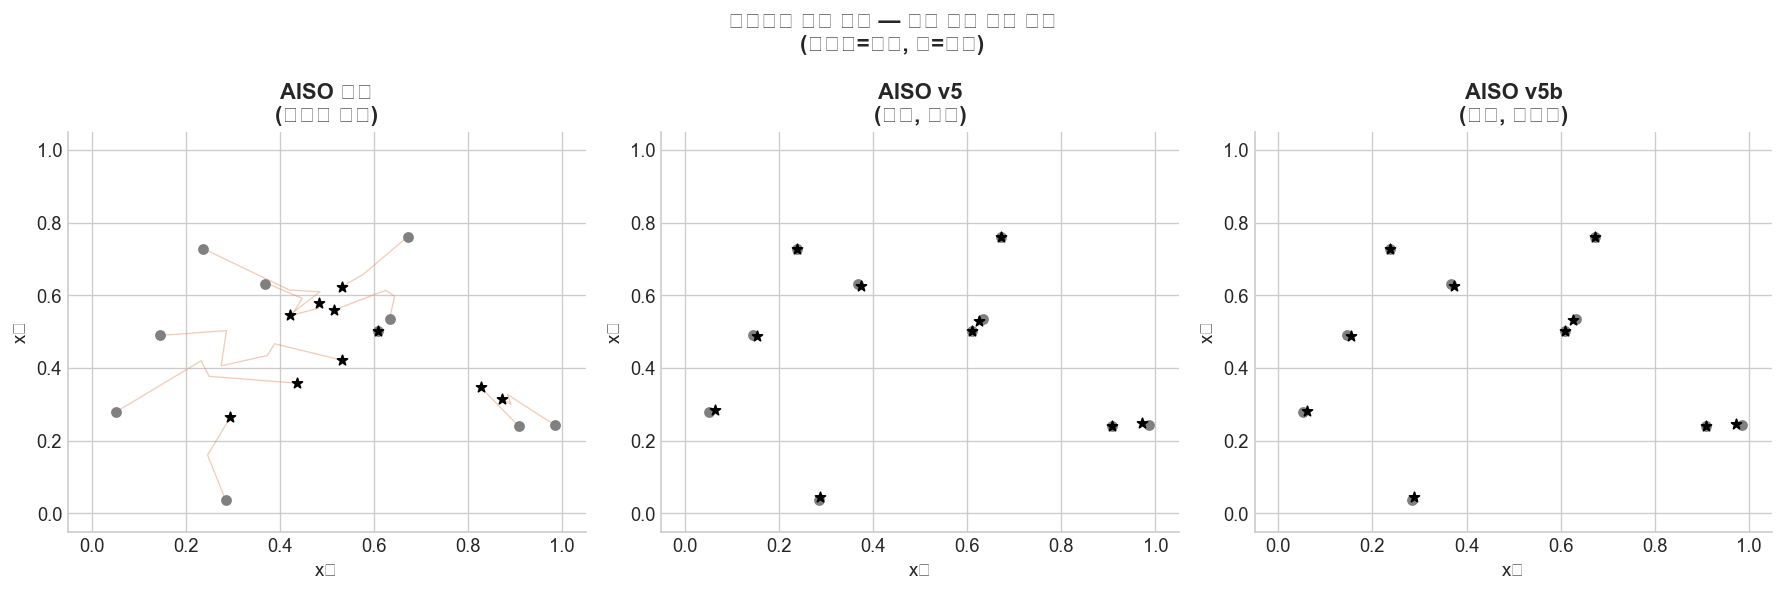

궤도 시각화 완료


In [4]:
# K=2에서 에이전트 궤도 시각화 — 삼체 특성 확인
# AISO 원본 vs v5 vs v5b 의 탐색 패턴 차이

def get_trajectories(mode, K2=2, n_agents=10, n_iter=60, seed=42):
    np.random.seed(seed)
    n_types = N_TYPES
    if mode == 'original':
        M = np.random.uniform(0, 2, (n_types, n_types))
    else:
        M = np.random.uniform(-1, 2, (n_types, n_types))
        if mode == 'v5b': np.fill_diagonal(M, 0)

    X = np.random.rand(n_agents, K2)
    W = np.random.dirichlet(np.ones(n_types), n_agents)
    f2 = make_ackley()
    S = np.array([f2(np.pad(X[i], (0, K-K2))) for i in range(n_agents)])
    traj = [X.copy()]

    for _ in range(n_iter):
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(n_agents):
            diff = X - X[i]
            if mode == 'original':
                j = np.random.randint(n_agents)
                while j == i: j = np.random.randint(n_agents)
                c = float(W[i] @ M @ W[j])
                nX = np.clip(X[i] + 0.3*c*(X[j]-X[i]), 0, 1)
            else:
                F = (C[i][:, None] * diff).sum(axis=0) / (n_agents-1)
                nX = np.clip(X[i] + ALPHA*F, 0, 1)
            ns = f2(np.pad(nX, (0, K-K2)))
            if ns < S[i]:
                X[i] = nX; S[i] = ns
                if mode == 'original':
                    W[i] = (1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
                else:
                    bj = np.argmax(C[i])
                    W[i] = (1-BETA)*W[i]+BETA*W[bj]; W[i]/=W[i].sum()
        traj.append(X.copy())
    return np.array(traj)  # (n_iter+1, n_agents, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
modes = [('original','AISO 원본\n(단방향 당김)','#DD8452'),
         ('v5',     'AISO v5\n(삼체, 대칭)','#C44E52'),
         ('v5b',    'AISO v5b\n(삼체, 비대칭)','#55A868')]

for ax, (mode, title, color) in zip(axes, modes):
    traj = get_trajectories(mode)
    n_ag = traj.shape[1]
    for a in range(n_ag):
        xs, ys = traj[:, a, 0], traj[:, a, 1]
        ax.plot(xs, ys, alpha=0.4, linewidth=0.8, color=color)
        ax.scatter(xs[0],  ys[0],  s=30, color='gray',  zorder=4)
        ax.scatter(xs[-1], ys[-1], s=40, color='black', zorder=5, marker='*')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.suptitle('에이전트 궤도 비교 — 삼체 역학 탐색 패턴\n(회색점=시작, ★=종료)', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_v5_trajectories.png', bbox_inches='tight')
plt.show()
print('궤도 시각화 완료')

## 전체 벤치마크


── Sphere ──
  PSO                   1.290 ± 0.916
  AISO                  8.430 ± 2.114  (-553.5% vs PSO)
  AISO_v5               7.260 ± 1.694  (-462.8% vs PSO)
  AISO_v5b              7.461 ± 1.708  (-478.4% vs PSO)

── Rosenbrock ──
  PSO                 133.143 ± 60.462
  AISO                171.842 ± 52.891  (-29.1% vs PSO)
  AISO_v5             154.290 ± 34.651  (-15.9% vs PSO)
  AISO_v5b            158.900 ± 36.555  (-19.3% vs PSO)

── Zakharov ──
  PSO                 134.343 ± 31.167
  AISO                 11.279 ± 2.760  (+91.6% vs PSO)
  AISO_v5              10.139 ± 4.067  (+92.5% vs PSO)
  AISO_v5b             10.854 ± 4.255  (+91.9% vs PSO)

── Dixon-Price ──
  PSO                4260.879 ± 15928.253
  AISO               7683.821 ± 7118.824  (-80.3% vs PSO)
  AISO_v5            5331.344 ± 3907.286  (-25.1% vs PSO)
  AISO_v5b           5632.398 ± 3876.122  (-32.2% vs PSO)

── Rastrigin ──
  PSO                 173.836 ± 36.602
  AISO                182.416 ± 19.744  (-4.

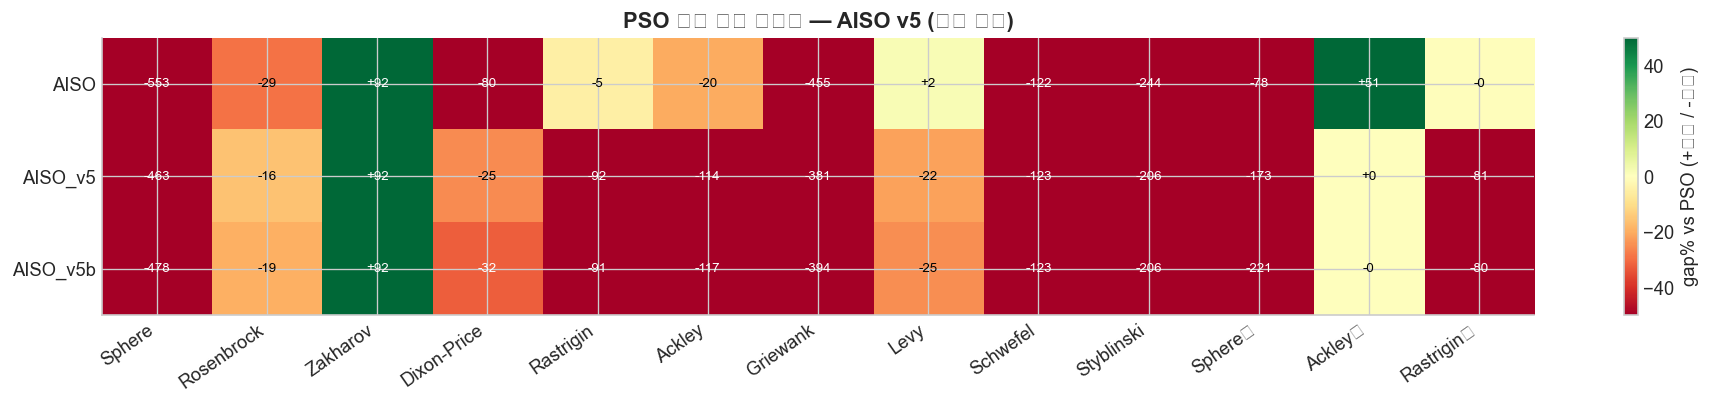

  AISO v5 결과 요약
  AISO          :  3/13승 | 전체gap -111.0% | 노이즈gap -9.2%
  AISO_v5       :  2/13승 | 전체gap -123.2% | 노이즈gap -84.5%
  AISO_v5b      :  1/13승 | 전체gap -130.3% | 노이즈gap -100.4%


In [5]:
all_results = {}
for b in BENCHMARKS:
    fname = b.__name__
    print(f'\n── {fname} ──')
    all_results[fname] = {}
    for aname, afunc in ALGOS.items():
        scores = [afunc(b, K, seed=42+r) for r in range(N_RUNS)]
        all_results[fname][aname] = scores
        m = np.mean(scores)
        if aname != 'PSO':
            pso_m = np.mean(all_results[fname]['PSO'])
            gap = -(m-pso_m)/(abs(pso_m)+1e-8)*100
            print(f'  {aname:<14} {m:>12.3f} ± {np.std(scores):.3f}  ({gap:+.1f}% vs PSO)')
        else:
            print(f'  {aname:<14} {m:>12.3f} ± {np.std(scores):.3f}')
print('\n✓ 완료!')

# ── 히트맵 ──────────────────────────────────────────────────
fnames = list(all_results.keys())
anames = list(ALGOS.keys())
row_labels = [a for a in anames if a != 'PSO']
COLORS = {'PSO':'#4C72B0','AISO':'#DD8452','AISO_v5':'#C44E52','AISO_v5b':'#55A868'}

gap_mat = np.zeros((len(row_labels), len(fnames)))
for ri, an in enumerate(row_labels):
    for ci, fn in enumerate(fnames):
        pso_m = np.mean(all_results[fn]['PSO'])
        ai_m  = np.mean(all_results[fn][an])
        gap_mat[ri, ci] = -(ai_m-pso_m)/(abs(pso_m)+1e-8)*100

fig, ax = plt.subplots(figsize=(16, 3.5))
im = ax.imshow(gap_mat, cmap='RdYlGn', aspect='auto', vmin=-50, vmax=50)
plt.colorbar(im, ax=ax, label='gap% vs PSO (+좋음 / -나쁨)')
ax.set_xticks(range(len(fnames)))
ax.set_xticklabels([f.replace('_N','★') for f in fnames], rotation=35, ha='right')
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
ax.set_title('PSO 대비 성능 히트맵 — AISO v5 (삼체 역학)', fontweight='bold')
for ri in range(len(row_labels)):
    for ci in range(len(fnames)):
        v = gap_mat[ri, ci]
        ax.text(ci, ri, f'{v:+.0f}', ha='center', va='center', fontsize=8,
                color='black' if abs(v)<30 else 'white')
plt.tight_layout()
plt.savefig('aiso_v5_heatmap.png', bbox_inches='tight')
plt.show()

# ── 승수 요약 ────────────────────────────────────────────────
standard_fns = [f for f in fnames if '_N' not in f]
noisy_fns    = [f for f in fnames if '_N' in f]

print('='*60)
print('  AISO v5 결과 요약')
print('='*60)
for an in row_labels:
    wins  = sum(np.mean(all_results[fn][an])<np.mean(all_results[fn]['PSO']) for fn in fnames)
    g_all = np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in fnames])
    g_n   = np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in noisy_fns])
    print(f'  {an:<14}: {wins:2d}/13승 | 전체gap {g_all:+.1f}% | 노이즈gap {g_n:+.1f}%')
print('='*60)